# The Cost Cliff: Intraday Strategy Reality Check

**Docker image**: `ml4t`

This notebook demonstrates the dramatic impact of transaction costs on intraday
trading strategies. A strategy that posts a high gross Sharpe can become
unprofitable or marginal once realistic costs are applied.

**Key Insight**: The "cost cliff" refers to the collapse in net performance
when moving from daily to intraday strategies. Even a Gross Sharpe of 2.5 can
become deeply negative after realistic execution costs, because per-trade
friction compounds over thousands of annual round-trips.

**Why This Matters**:
- Intraday strategies are primarily the domain of institutions with cost advantages
- Retail traders face much higher hurdles for intraday profitability
- The same alpha can be valuable or worthless depending on execution infrastructure

**Learning Objectives**
- Quantify the gross-to-net collapse for realistic intraday cost stacks
- Compare retail, institutional, and HFT execution assumptions on the same signal
- Estimate the trade-frequency ceiling implied by a target net Sharpe
- Use the cost cliff as a publication-quality sanity check for intraday claims

**Book Reference:** Chapter 18: Section 18.8 (Practical Guardrails)

**Prerequisites:** Read [`02_spread_estimation`](02_spread_estimation.ipynb) for spread realism and
[`09_frequency_tradeoff`](09_frequency_tradeoff.ipynb) for the slower-frequency guardrail framing.

## Setup

In [1]:
"""The Cost Cliff - Intraday Sharpe collapse and break-even frequency analysis."""

import warnings
from dataclasses import dataclass

warnings.filterwarnings("ignore")

import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

import utils  # noqa: F401
from data import load_nasdaq100_bars
from utils.reproducibility import set_global_seeds

In [2]:
# The retail half-spread that anchors the cost stacks is measured from real
# AlgoSeek NASDAQ-100 minute-bar quotes over the window below.
SPREAD_START_DATE = "2021-12-01"
SPREAD_END_DATE = "2021-12-31"
SEED = 42

In [3]:
set_global_seeds(SEED)

## 1. Anchoring the Spread to Real NASDAQ-100 Quotes

The cost cliff is only credible if the spread that drives it is real. We load
AlgoSeek NASDAQ-100 minute bars, compute each interval's relative quoted spread,
and take the **cross-sectional** distribution of per-symbol volume-weighted
spreads. The median name — not the most liquid mega-cap — is the right anchor
for a strategy that trades the whole index.

In [4]:
def measure_nasdaq100_spreads(start_date: str, end_date: str) -> pl.DataFrame:
    """Per-symbol volume-weighted relative quoted spread (bps) over the regular session."""
    return (
        load_nasdaq100_bars(
            start_date=start_date,
            end_date=end_date,
            include_microstructure=True,
            lazy=True,
        )
        .select("symbol", "timestamp", "volume", "close_bid_price", "close_ask_price")
        .filter(
            (pl.col("close_bid_price") > 0)
            & (pl.col("close_ask_price") >= pl.col("close_bid_price"))
            & (pl.col("volume") > 0)
        )
        .with_columns(
            minute_of_day=pl.col("timestamp").dt.hour().cast(pl.Int32) * 60
            + pl.col("timestamp").dt.minute().cast(pl.Int32),
            rel_spread_bps=(
                (pl.col("close_ask_price") - pl.col("close_bid_price"))
                / ((pl.col("close_ask_price") + pl.col("close_bid_price")) / 2)
                * 1e4
            ),
        )
        .filter((pl.col("minute_of_day") >= 570) & (pl.col("minute_of_day") < 960))
        .group_by("symbol")
        .agg(
            vw_rel_spread_bps=(pl.col("rel_spread_bps") * pl.col("volume")).sum()
            / pl.col("volume").sum()
        )
        .sort("vw_rel_spread_bps")
        .collect()
    )

In [5]:
spread_df = measure_nasdaq100_spreads(SPREAD_START_DATE, SPREAD_END_DATE)
median_rel_spread_bps = float(spread_df["vw_rel_spread_bps"].median())
# The cost of crossing once is half the quoted spread.
MEASURED_HALF_SPREAD_BPS = median_rel_spread_bps / 2.0

print(f"NASDAQ-100 symbols measured: {spread_df.height}")
print(f"Median per-symbol relative spread: {median_rel_spread_bps:.2f} bps")
print(f"Measured half-spread (cost to cross): {MEASURED_HALF_SPREAD_BPS:.2f} bps")
print(f"Most liquid name:  {spread_df['vw_rel_spread_bps'][0]:.2f} bps")
print(f"Least liquid name: {spread_df['vw_rel_spread_bps'][-1]:.2f} bps")

NASDAQ-100 symbols measured: 99
Median per-symbol relative spread: 8.08 bps
Measured half-spread (cost to cross): 4.04 bps
Most liquid name:  0.85 bps
Least liquid name: 28.10 bps


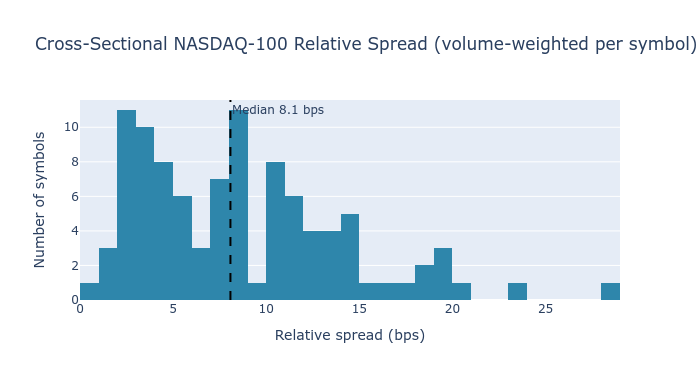

In [6]:
# Show the cross-sectional spread distribution the anchor is drawn from.
fig = go.Figure()
fig.add_histogram(x=spread_df["vw_rel_spread_bps"].to_list(), nbinsx=30, marker_color="#2E86AB")
fig.add_vline(
    x=median_rel_spread_bps,
    line_dash="dash",
    line_color="black",
    annotation_text=f"Median {median_rel_spread_bps:.1f} bps",
)
fig.update_layout(
    title="Cross-Sectional NASDAQ-100 Relative Spread (volume-weighted per symbol)",
    xaxis_title="Relative spread (bps)",
    yaxis_title="Number of symbols",
    height=380,
)
fig.show()

**Finding**: NASDAQ-100 spreads span more than an order of magnitude — the most
liquid mega-cap quotes under a basis point while the median name sits near 8 bps
relative, a half-spread of about 4 bps to cross. A strategy that trades the
whole index pays the median, not the mega-cap, so that is the retail spread we
carry into the cost stack below.

## 2. Intraday Cost Components

Intraday trading incurs costs at multiple levels. The spread term is the
measured half-spread above; market impact, slippage, and fees are institutional
cost assumptions layered on top.

In [7]:
@dataclass
class IntradayCostStack:
    """Complete cost stack for intraday trading."""

    # Market-related costs (per trade, one-way, bps)
    spread_half: float = 3.0  # Half spread cost for crossing
    market_impact: float = 2.0  # Price impact from trade
    slippage: float = 1.5  # Execution slippage

    # Fee-related costs (per trade, one-way, bps)
    commission: float = 0.5  # Broker commission
    exchange_fee: float = 0.3  # Exchange fees
    clearing_fee: float = 0.1  # Clearing costs

    # Financing costs (annualized)
    margin_rate: float = 0.055  # 5.5% margin interest
    locate_fee: float = 0.02  # 2% for hard-to-borrow shorts

    @property
    def total_per_trade_bps(self) -> float:
        """Total cost per trade (one-way) in bps."""
        return (
            self.spread_half
            + self.market_impact
            + self.slippage
            + self.commission
            + self.exchange_fee
            + self.clearing_fee
        )

    @property
    def round_trip_bps(self) -> float:
        """Total round-trip cost in bps."""
        return 2 * self.total_per_trade_bps

### Cost Scenario Presets

All three desks face the same measured spread but capture different fractions of
it: retail crosses and pays the full half-spread, an institutional desk works
orders to cross only partway, and an HFT desk provides liquidity and pays no
spread (earning rebates instead). Impact, slippage, and fees scale with
execution sophistication.

In [8]:
RETAIL_INTRADAY = IntradayCostStack(
    spread_half=MEASURED_HALF_SPREAD_BPS,  # crosses and pays the full measured half-spread
    market_impact=3.0,
    slippage=2.0,
    commission=0.0,  # Commission-free broker
    exchange_fee=0.3,
    clearing_fee=0.1,
)

INSTITUTIONAL_INTRADAY = IntradayCostStack(
    spread_half=0.375 * MEASURED_HALF_SPREAD_BPS,  # works orders to cross only partway
    market_impact=2.5,
    slippage=1.0,
    commission=0.3,
    exchange_fee=0.2,
    clearing_fee=0.05,
)

HFT_INTRADAY = IntradayCostStack(
    spread_half=0.0,  # Provide liquidity, earn spread
    market_impact=0.5,
    slippage=0.2,
    commission=0.05,
    exchange_fee=-0.2,  # Rebates!
    clearing_fee=0.02,
)

In [9]:
print("Intraday Cost Comparison (bps):")
cost_rows = []
for component in [
    "spread_half",
    "market_impact",
    "slippage",
    "commission",
    "exchange_fee",
    "clearing_fee",
]:
    cost_rows.append(
        {
            "Component": component,
            "Retail": getattr(RETAIL_INTRADAY, component),
            "Institutional": getattr(INSTITUTIONAL_INTRADAY, component),
            "HFT": getattr(HFT_INTRADAY, component),
        }
    )
cost_rows.append(
    {
        "Component": "TOTAL (one-way)",
        "Retail": RETAIL_INTRADAY.total_per_trade_bps,
        "Institutional": INSTITUTIONAL_INTRADAY.total_per_trade_bps,
        "HFT": HFT_INTRADAY.total_per_trade_bps,
    }
)
cost_rows.append(
    {
        "Component": "TOTAL (round-trip)",
        "Retail": RETAIL_INTRADAY.round_trip_bps,
        "Institutional": INSTITUTIONAL_INTRADAY.round_trip_bps,
        "HFT": HFT_INTRADAY.round_trip_bps,
    }
)
pl.DataFrame(cost_rows)

Intraday Cost Comparison (bps):


Component,Retail,Institutional,HFT
str,f64,f64,f64
"""spread_half""",4.039377,1.514766,0.0
"""market_impact""",3.0,2.5,0.5
"""slippage""",2.0,1.0,0.2
"""commission""",0.0,0.3,0.05
"""exchange_fee""",0.3,0.2,-0.2
"""clearing_fee""",0.1,0.05,0.02
"""TOTAL (one-way)""",9.439377,5.564766,0.57
"""TOTAL (round-trip)""",18.878754,11.129533,1.14


**Finding**: The round-trip stack sets the baseline hurdle. Retail intraday
trading starts several bps behind before alpha enters the picture, while
institutional and HFT setups survive only because they negotiate much smaller
spread and fee drag.

## 3. Intraday OFI Strategy Example

Consider a realistic intraday strategy based on Order Flow Imbalance (OFI):
- Trades NASDAQ-100 stocks
- Signals based on 5-minute OFI aggregates
- Multiple trades per day per stock

In [10]:
@dataclass
class IntradayStrategy:
    """Parameters for an intraday strategy."""

    name: str
    gross_sharpe: float  # Gross Sharpe ratio
    annual_vol: float  # Annual volatility
    trades_per_day: int  # Number of round-trip trades per day
    avg_holding_period_minutes: int  # Average time in position


# Define strategies with different profiles
OFI_AGGRESSIVE = IntradayStrategy(
    name="OFI Aggressive (High Frequency)",
    gross_sharpe=2.5,
    annual_vol=0.20,
    trades_per_day=50,
    avg_holding_period_minutes=15,
)

OFI_MODERATE = IntradayStrategy(
    name="OFI Moderate",
    gross_sharpe=2.0,
    annual_vol=0.15,
    trades_per_day=20,
    avg_holding_period_minutes=30,
)

OFI_CONSERVATIVE = IntradayStrategy(
    name="OFI Conservative (Day Trading)",
    gross_sharpe=1.5,
    annual_vol=0.12,
    trades_per_day=5,
    avg_holding_period_minutes=90,
)

### Net Performance Calculator

In [11]:
def calculate_intraday_net_performance(
    strategy: IntradayStrategy,
    costs: IntradayCostStack,
    trading_days: int = 252,
) -> dict:
    """Calculate gross-to-net metrics for an intraday strategy."""
    gross_return = strategy.gross_sharpe * strategy.annual_vol
    annual_trades = strategy.trades_per_day * trading_days

    annual_cost_bps = annual_trades * costs.round_trip_bps
    annual_cost = annual_cost_bps / 10000
    net_return = gross_return - annual_cost

    net_sharpe = net_return / strategy.annual_vol if strategy.annual_vol > 0 else 0.0
    sharpe_reduction = 0.0
    if strategy.gross_sharpe > 0:
        sharpe_reduction = (strategy.gross_sharpe - net_sharpe) / strategy.gross_sharpe

    return {
        "strategy": strategy.name,
        "gross_sharpe": strategy.gross_sharpe,
        "gross_return": gross_return,
        "trades_per_day": strategy.trades_per_day,
        "annual_trades": annual_trades,
        "cost_bps_per_trade": costs.round_trip_bps,
        "annual_cost_bps": annual_cost_bps,
        "annual_cost": annual_cost,
        "net_return": net_return,
        "net_sharpe": net_sharpe,
        "sharpe_reduction_pct": sharpe_reduction * 100,
        "viable": net_sharpe > 0.5,
    }

## 4. The Cost Cliff Demonstration

Let's see how the same strategy performs with different cost structures. The
spread term is the measured NASDAQ-100 median half-spread; the gross Sharpe and
trade-frequency profiles are hypothetical strategy scenarios, since no single
real strategy spans the retail-to-HFT execution range.

In [12]:
strategies = [OFI_AGGRESSIVE, OFI_MODERATE, OFI_CONSERVATIVE]
cost_scenarios = [
    ("Retail", RETAIL_INTRADAY),
    ("Institutional", INSTITUTIONAL_INTRADAY),
    ("HFT", HFT_INTRADAY),
]

results = []
for strategy in strategies:
    for cost_name, costs in cost_scenarios:
        perf = calculate_intraday_net_performance(strategy, costs)
        perf["cost_type"] = cost_name
        results.append(perf)

results_df = pl.DataFrame(results)

In [13]:
print("\nThe Cost Cliff: Intraday Strategy Analysis")
results_df.select(
    pl.col("strategy"),
    pl.col("cost_type"),
    pl.col("cost_bps_per_trade").round(1).alias("cost_per_trade_bps"),
    (pl.col("annual_cost") * 100).round(1).alias("annual_cost_%"),
    pl.col("net_sharpe").round(2),
    pl.col("viable"),
)


The Cost Cliff: Intraday Strategy Analysis


strategy,cost_type,cost_per_trade_bps,annual_cost_%,net_sharpe,viable
str,str,f64,f64,f64,bool
"""OFI Aggressive (High Frequency…","""Retail""",18.9,2378.7,-116.44,false
"""OFI Aggressive (High Frequency…","""Institutional""",11.1,1402.3,-67.62,false
"""OFI Aggressive (High Frequency…","""HFT""",1.1,143.6,-4.68,false
"""OFI Moderate""","""Retail""",18.9,951.5,-61.43,false
"""OFI Moderate""","""Institutional""",11.1,560.9,-35.4,false
"""OFI Moderate""","""HFT""",1.1,57.5,-1.83,false
"""OFI Conservative (Day Trading)""","""Retail""",18.9,237.9,-18.32,false
"""OFI Conservative (Day Trading)""","""Institutional""",11.1,140.2,-10.19,false
"""OFI Conservative (Day Trading)""","""HFT""",1.1,14.4,0.3,false


**Finding**: The strategy table shows the cost cliff numerically before the
chart makes it visual. Viability flips because annualized trading costs scale
with turnover much faster than realistic gross Sharpe does.

## 5. Visualizing the Cost Cliff

In [14]:
fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=[s.name.split("(")[0].strip() for s in strategies],
    shared_yaxes=True,
)

colors = {"Retail": "#d62728", "Institutional": "#ff7f0e", "HFT": "#2ca02c"}

for i, strategy in enumerate(strategies, 1):
    subset = results_df.filter(pl.col("strategy") == strategy.name)

    # Gross Sharpe (same for all)
    fig.add_trace(
        go.Bar(
            x=["Gross"],
            y=[strategy.gross_sharpe],
            name="Gross SR" if i == 1 else None,
            marker_color="steelblue",
            showlegend=(i == 1),
        ),
        row=1,
        col=i,
    )

    # Net Sharpe by cost type
    for row in subset.iter_rows(named=True):
        fig.add_trace(
            go.Bar(
                x=[row["cost_type"]],
                y=[row["net_sharpe"]],
                name=row["cost_type"] if i == 1 else None,
                marker_color=colors[row["cost_type"]],
                showlegend=(i == 1),
            ),
            row=1,
            col=i,
        )

### Add Viability Thresholds

In [15]:
for i, _strategy in enumerate(strategies, 1):
    if i == 1:
        fig.add_hline(
            y=0.5,
            line_dash="dash",
            line_color="gray",
            annotation_text="Viable",
            row=1,
            col=i,
        )
    else:
        fig.add_hline(y=0.5, line_dash="dash", line_color="gray", row=1, col=i)
    fig.add_hline(y=0, line_dash="dot", line_color="red", row=1, col=i)

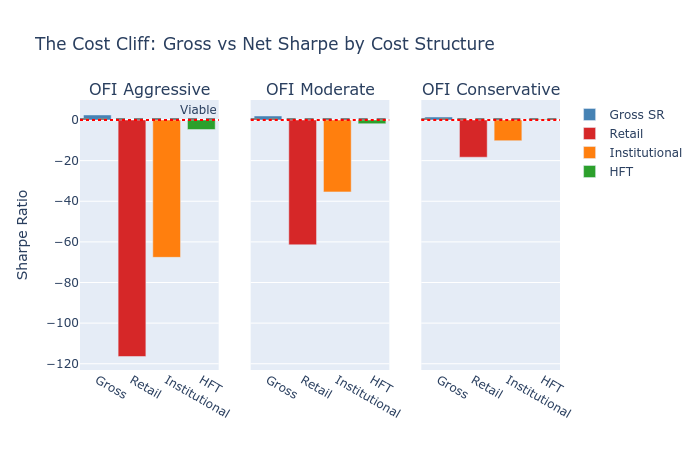

In [16]:
fig.update_layout(
    title="The Cost Cliff: Gross vs Net Sharpe by Cost Structure",
    yaxis_title="Sharpe Ratio",
    height=450,
    showlegend=True,
)

fig.show()

**Finding**: The cost-cliff chart is the notebook’s main diagnostic. The same
gross Sharpe can stay viable for an HFT desk and fail outright for a retail
desk because execution quality, not signal quality, dominates net results.

## 6. Sharpe Degradation Analysis

The percentage reduction in Sharpe tells the story:

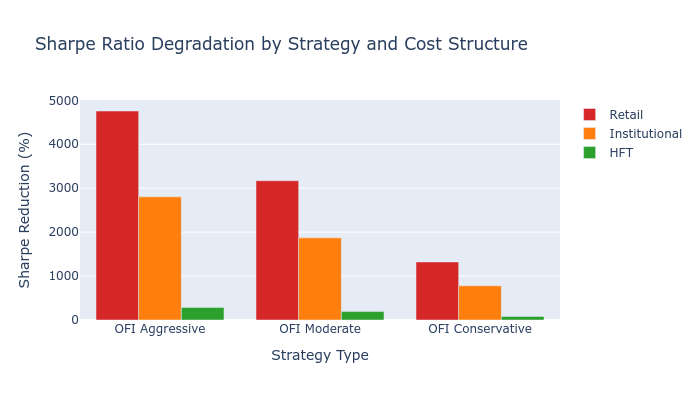

In [17]:
fig = go.Figure()

x_labels = []
retail_deg = []
inst_deg = []
hft_deg = []

for strategy in strategies:
    x_labels.append(strategy.name.split("(")[0].strip())
    subset = results_df.filter(pl.col("strategy") == strategy.name)

    for row in subset.iter_rows(named=True):
        if row["cost_type"] == "Retail":
            retail_deg.append(row["sharpe_reduction_pct"])
        elif row["cost_type"] == "Institutional":
            inst_deg.append(row["sharpe_reduction_pct"])
        else:
            hft_deg.append(row["sharpe_reduction_pct"])

fig.add_trace(go.Bar(x=x_labels, y=retail_deg, name="Retail", marker_color="#d62728"))
fig.add_trace(go.Bar(x=x_labels, y=inst_deg, name="Institutional", marker_color="#ff7f0e"))
fig.add_trace(go.Bar(x=x_labels, y=hft_deg, name="HFT", marker_color="#2ca02c"))

fig.update_layout(
    title="Sharpe Ratio Degradation by Strategy and Cost Structure",
    yaxis_title="Sharpe Reduction (%)",
    xaxis_title="Strategy Type",
    barmode="group",
    height=400,
)

#### Annotate Maximum Sharpe Loss

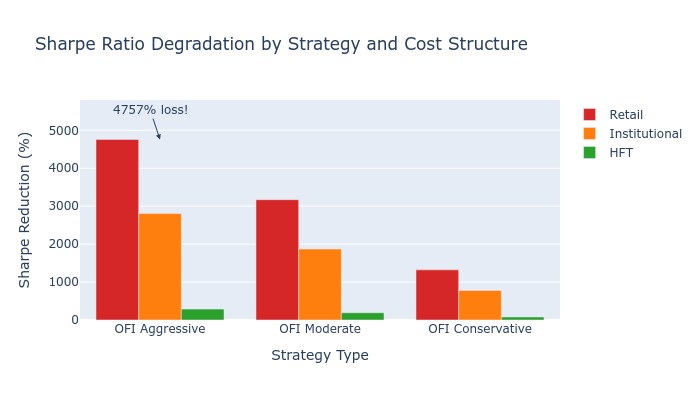

In [18]:
# Add annotation for dramatic example
fig.add_annotation(
    x="OFI Aggressive",
    y=max(retail_deg),
    text=f"{max(retail_deg):.0f}% loss!",
    showarrow=True,
    arrowhead=2,
)

fig.show()

**Finding**: Sharpe degradation is often the cleanest communication device for
readers. It translates abstract basis points into the share of the original
signal that disappears once the strategy is traded realistically.

## 7. Annual Cost as Percentage of Gross Return

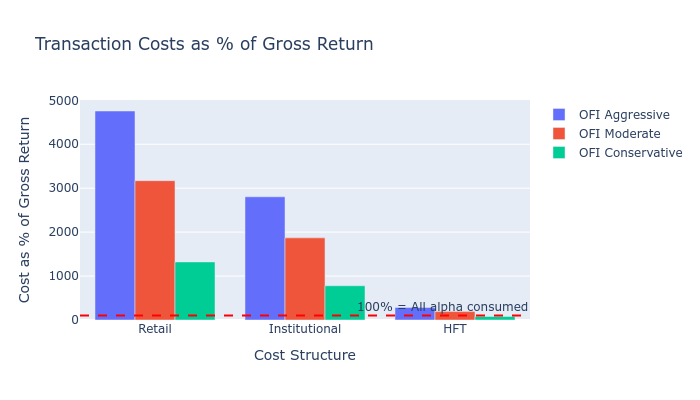

In [19]:
fig = go.Figure()

for strategy in strategies:
    subset = results_df.filter(pl.col("strategy") == strategy.name)
    strategy_label = strategy.name.split("(")[0].strip()

    costs_data = []
    for row in subset.iter_rows(named=True):
        gross_ret = row["gross_return"]
        cost_pct = (row["annual_cost"] / gross_ret * 100) if gross_ret > 0 else 100
        costs_data.append({"cost_type": row["cost_type"], "cost_pct": cost_pct})

    fig.add_trace(
        go.Bar(
            x=[d["cost_type"] for d in costs_data],
            y=[d["cost_pct"] for d in costs_data],
            name=strategy_label,
        )
    )

fig.add_hline(
    y=100, line_dash="dash", line_color="red", annotation_text="100% = All alpha consumed"
)

fig.update_layout(
    title="Transaction Costs as % of Gross Return",
    yaxis_title="Cost as % of Gross Return",
    xaxis_title="Cost Structure",
    barmode="group",
    height=400,
)

fig.show()

**Finding**: Cost as a share of gross return is the clearest sanity check for
intraday claims. Once annual cost approaches 100% of gross return, the strategy
has no margin for model error, slippage misses, or live degradation.

## 8. Break-Even Analysis for Intraday Strategies

In [20]:
def calculate_break_even_trades(
    target_net_sharpe: float,
    gross_sharpe: float,
    annual_vol: float,
    costs: IntradayCostStack,
    trading_days: int = 252,
) -> int:
    """
    Calculate maximum trades per day for a target net Sharpe.

    Args:
        target_net_sharpe: Minimum acceptable net Sharpe
        gross_sharpe: Gross Sharpe ratio
        annual_vol: Annual volatility
        costs: Cost structure
        trading_days: Trading days per year

    Returns:
        Maximum trades per day
    """
    gross_return = gross_sharpe * annual_vol
    target_net_return = target_net_sharpe * annual_vol
    max_annual_cost = gross_return - target_net_return

    # Cost per trade (round-trip)
    cost_per_trade = costs.round_trip_bps / 10000

    if cost_per_trade <= 0:
        return 999  # No cost constraint

    max_annual_trades = max_annual_cost / cost_per_trade
    max_daily_trades = max_annual_trades / trading_days

    return max(0, int(max_daily_trades))

In [21]:
print("\nBreak-Even Trade Frequency (max trades/day for Net Sharpe >= 0.5):")
be_rows = []
for gs in [1.5, 2.0, 2.5, 3.0]:
    row = {"Gross SR": gs}
    for cost_name, cost_obj in cost_scenarios:
        max_trades = calculate_break_even_trades(
            target_net_sharpe=0.5,
            gross_sharpe=gs,
            annual_vol=0.15,
            costs=cost_obj,
        )
        row[cost_name] = max_trades
    be_rows.append(row)
pl.DataFrame(be_rows)


Break-Even Trade Frequency (max trades/day for Net Sharpe >= 0.5):


Gross SR,Retail,Institutional,HFT
f64,i64,i64,i64
1.5,0,0,5
2.0,0,0,7
2.5,0,1,10
3.0,0,1,13


**Interpretation**: The break-even table converts cost assumptions into a concrete
trade-frequency ceiling. The more expensive the execution stack, the fewer intraday
round trips the strategy can survive while remaining above a minimum net Sharpe.

## 9. Cost-Structure Comparison

### Key Insights

1. **Retail intraday is fragile**: high-turnover variants can flip from
   strong gross Sharpe to deeply negative net Sharpe once spread, impact,
   and fees are applied.

2. **Institutional execution quality matters**: lower per-trade costs
   materially expand viable turnover capacity relative to retail.

3. **Viability threshold**: Net Sharpe < 0.5 is a practical warning zone.
   Most intraday strategies fail this gate at retail or institutional cost
   levels.

4. **Why backtests overstate intraday edge**: optimistic slippage and
   incomplete spread/impact modeling can hide the true cost cliff.

5. **Practical policy**: default to daily-or-slower unless infrastructure
   supports robust intraday execution and monitoring.

## 10. Summary Table

In [22]:
# Create comprehensive summary
summary_data = []
for strategy in strategies:
    for cost_name, costs in cost_scenarios:
        perf = calculate_intraday_net_performance(strategy, costs)

        summary_data.append(
            {
                "Strategy": strategy.name.split("(")[0].strip(),
                "Trades/Day": strategy.trades_per_day,
                "Cost Type": cost_name,
                "Gross SR": strategy.gross_sharpe,
                "Net SR": round(perf["net_sharpe"], 2),
                "SR Loss (%)": round(perf["sharpe_reduction_pct"], 0),
                "Viable": "YES" if perf["viable"] else "NO",
            }
        )

summary_df = pl.DataFrame(summary_data)
print("\nComprehensive Summary: The Cost Cliff")
summary_df


Comprehensive Summary: The Cost Cliff


Strategy,Trades/Day,Cost Type,Gross SR,Net SR,SR Loss (%),Viable
str,i64,str,f64,f64,f64,str
"""OFI Aggressive""",50,"""Retail""",2.5,-116.44,4757.0,"""NO"""
"""OFI Aggressive""",50,"""Institutional""",2.5,-67.62,2805.0,"""NO"""
"""OFI Aggressive""",50,"""HFT""",2.5,-4.68,287.0,"""NO"""
"""OFI Moderate""",20,"""Retail""",2.0,-61.43,3172.0,"""NO"""
"""OFI Moderate""",20,"""Institutional""",2.0,-35.4,1870.0,"""NO"""
"""OFI Moderate""",20,"""HFT""",2.0,-1.83,192.0,"""NO"""
"""OFI Conservative""",5,"""Retail""",1.5,-18.32,1322.0,"""NO"""
"""OFI Conservative""",5,"""Institutional""",1.5,-10.19,779.0,"""NO"""
"""OFI Conservative""",5,"""HFT""",1.5,0.3,80.0,"""NO"""


**Finding**: Under these cost assumptions, higher intraday turnover requires
substantially higher gross Sharpe to maintain the same net Sharpe. The exact
multiplier depends on the cost stack, the gross signal strength, and the
trade-frequency profile.

**Next**: See [`10_gross_vs_net_performance`](10_gross_vs_net_performance.ipynb) for the broader gross-to-net
waterfall and [`12_commission_slippage_comparison`](12_commission_slippage_comparison.ipynb) for explicit fee decomposition.
**Book**: Chapter 18, Section 18.8 discusses practical guardrails for costs.

## Key Takeaways

- **The cost cliff is a turnover phenomenon, not a market phenomenon**: the
  same gross Sharpe survives at HFT-grade execution and fails at retail
  execution because annualized round-trip cost scales linearly with trades
  per day.
- **Retail intraday is the binding constraint**: with the spread anchored to the
  measured median NASDAQ-100 half-spread, retail spread + fees consume the gross
  alpha before the strategy can earn it.
- **Cost-as-%-of-gross-return is the cleanest diagnostic**: once annual cost
  crosses 100% of gross return, the strategy has no margin for model error,
  live degradation, or slippage misses.
- **Break-even trade frequency is a deployment guardrail**: solving for the
  maximum trades per day under a target net Sharpe converts cost assumptions
  into a concrete turnover ceiling that can be enforced in production.
- **What is measured vs assumed**: the half-spread is measured from real
  NASDAQ-100 quotes; market impact, slippage, and fees are institutional cost
  assumptions, and the gross Sharpe / trade-frequency profiles are hypothetical
  strategy scenarios chosen to span the retail-to-HFT execution range.